# Customer Lifetime Value (CLTV) Prediction

## Project Overview

This project develops a machine learning model to predict Customer Lifetime Value (CLTV) using customer-level insurance data.

The objective is to identify patterns in customer characteristics and build a regression model capable of estimating the potential lifetime value of customers.

This project was developed as part of a **Customer Lifetime Value Prediction Hackathon**.


## Business Problem

Businesses need to understand which customers are likely to generate higher long-term value.

Accurate CLTV prediction can help businesses:

- Identify high-value customers
- Improve customer retention
- Prioritize marketing campaigns
- Allocate marketing resources
- Support customer segmentation
- Develop personalized customer strategies


## Project Objectives

- Understand the customer dataset
- Clean and preprocess the data
- Handle missing values
- Perform exploratory data analysis
- Engineer useful features
- Transform the target variable
- Encode categorical variables
- Train a machine learning regression model
- Evaluate model performance using R²
- Analyze feature importance
- Generate CLTV predictions for unseen customers
- Derive business-oriented insights


## 1. Import Libraries

In [10]:
%pip install matplotlib lightgbm

Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Load Dataset

The original competition notebook used Kaggle-specific paths. For this portfolio repository, the dataset is expected to be stored locally in the `data/` directory.

Expected structure:

```text
data/
├── train.csv
└── test.csv
```

If your actual filenames are different, update the paths below.


In [12]:
import pandas as pd

TRAIN_PATH = "C:/Users/honey/Git repositories/cltv-prediction-hackathon/data/train.csv"
TEST_PATH = "C:/Users/honey/Git repositories/cltv-prediction-hackathon/data/test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Training shape:", train.shape)
print("Test shape:", test.shape)
TEST_PATH ="C:/Users/honey/Git repositories/cltv-prediction-hackathon/data/test.csv"
TRAIN_PATH = "C:/Users/honey/Git repositories/cltv-prediction-hackathon/data/train.csv"
TEST_PATH = "C:/Users/honey/Git repositories/cltv-prediction-hackathon/data/test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Training shape:", train.shape) 
print("Test shape:", test.shape)
test = pd.read_csv(TEST_PATH)

print("Training shape:", train.shape) 
print("Test shape:", test.shape)


Training shape: (89392, 12)
Test shape: (59595, 11)
Training shape: (89392, 12)
Test shape: (59595, 11)
Training shape: (89392, 12)
Test shape: (59595, 11)


## 3. Dataset Overview

In [13]:
display(train.head())
display(test.head())


,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,1,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
1,2,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
2,3,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
3,4,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
4,5,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736


,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
0,89393,Female,Rural,High School,5L-10L,0,6,2134,More than 1,B,Silver
1,89394,Female,Urban,High School,2L-5L,0,4,4102,More than 1,A,Platinum
2,89395,Male,Rural,High School,5L-10L,1,7,2925,More than 1,B,Gold
3,89396,Female,Rural,Bachelor,More than 10L,1,2,0,More than 1,B,Silver
4,89397,Female,Urban,High School,2L-5L,0,5,14059,More than 1,B,Silver


In [14]:
print("Training information:")
train.info()

print("\nTest information:")
test.info()


Training information:
<class 'pandas.DataFrame'>
RangeIndex: 89392 entries, 0 to 89391
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              89392 non-null  int64
 1   gender          89392 non-null  str  
 2   area            89392 non-null  str  
 3   qualification   89392 non-null  str  
 4   income          89392 non-null  str  
 5   marital_status  89392 non-null  int64
 6   vintage         89392 non-null  int64
 7   claim_amount    89392 non-null  int64
 8   num_policies    89392 non-null  str  
 9   policy          89392 non-null  str  
 10  type_of_policy  89392 non-null  str  
 11  cltv            89392 non-null  int64
dtypes: int64(5), str(7)
memory usage: 8.2 MB

Test information:


<class 'pandas.DataFrame'>
RangeIndex: 59595 entries, 0 to 59594
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              59595 non-null  int64
 1   gender          59595 non-null  str  
 2   area            59595 non-null  str  
 3   qualification   59595 non-null  str  
 4   income          59595 non-null  str  
 5   marital_status  59595 non-null  int64
 6   vintage         59595 non-null  int64
 7   claim_amount    59595 non-null  int64
 8   num_policies    59595 non-null  str  
 9   policy          59595 non-null  str  
 10  type_of_policy  59595 non-null  str  
dtypes: int64(4), str(7)
memory usage: 5.0 MB


In [15]:
print("Training descriptive statistics:")
display(train.describe(include="all").T)


Training descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,"89,392.00",NaN,NaN,NaN,"44,696.50","25,805.39",1.00,"22,348.75","44,696.50","67,044.25","89,392.00"
gender,89392,2,Male,50497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,89392,2,Urban,62455,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qualification,89392,3,High School,46247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,89392,4,5L-10L,52716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,"89,392.00",NaN,NaN,NaN,0.58,0.49,0.00,0.00,1.00,1.00,1.00
vintage,"89,392.00",NaN,NaN,NaN,4.60,2.29,0.00,3.00,5.00,6.00,8.00
claim_amount,"89,392.00",NaN,NaN,NaN,"4,351.50","3,262.36",0.00,"2,406.00","4,089.00","6,094.00","31,894.00"
num_policies,89392,2,More than 1,60263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
policy,89392,3,A,56644,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
print("Missing values in training data:")
display(train.isnull().sum().sort_values(ascending=False))

print("\nMissing values in test data:")
display(test.isnull().sum().sort_values(ascending=False))


Missing values in training data:


id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64


Missing values in test data:


id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
dtype: int64

## 4. Exploratory Data Analysis

Exploratory analysis helps identify distributions, unusual values, and relationships that may be useful for CLTV prediction.


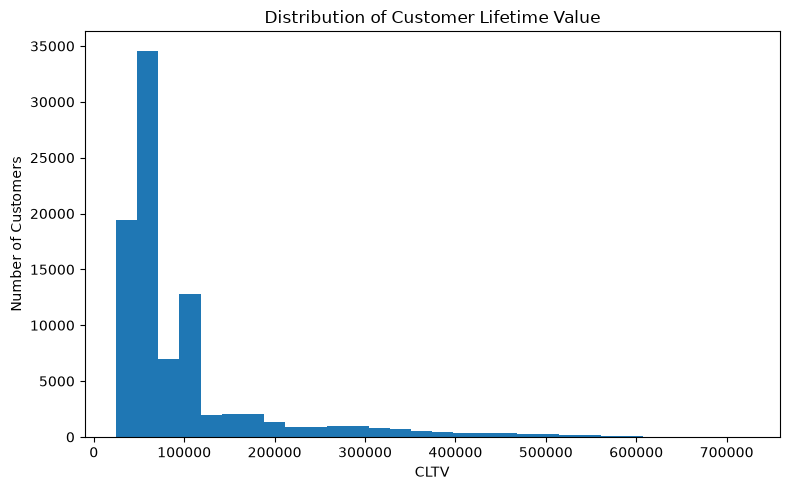

In [40]:
plt.figure(figsize=(8, 5))

plt.hist(train["cltv"], bins=30)

plt.title("Distribution of Customer Lifetime Value")
plt.xlabel("CLTV")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("../images/eda.png", dpi=300, bbox_inches="tight")
plt.show()

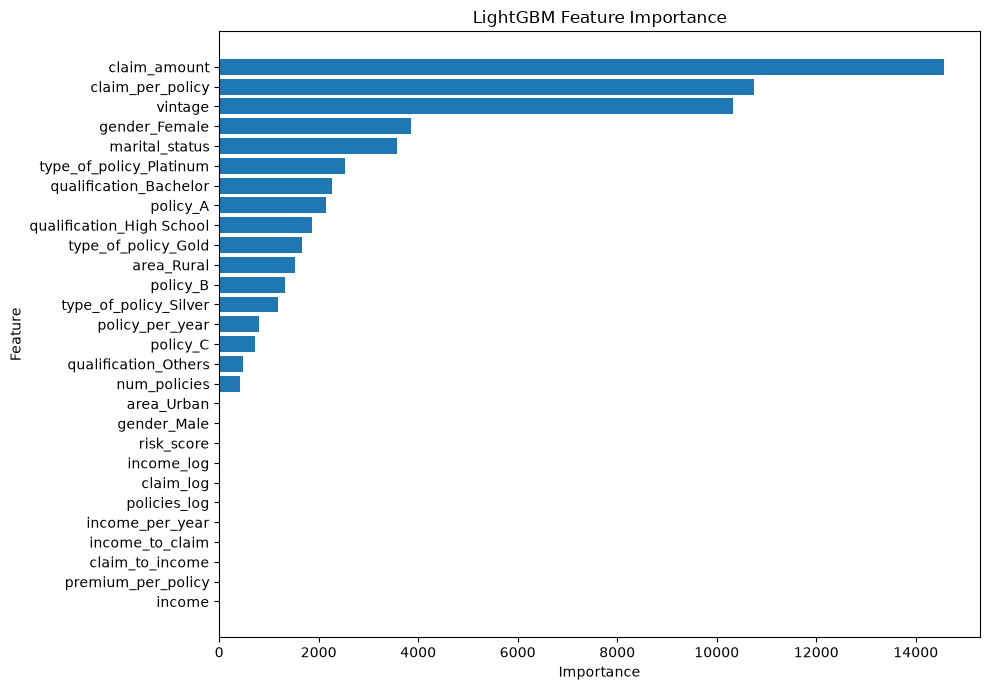

In [ ]:
from pyexpat import model
from re import X


importance = model.feature_importances_
features = X.columns

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

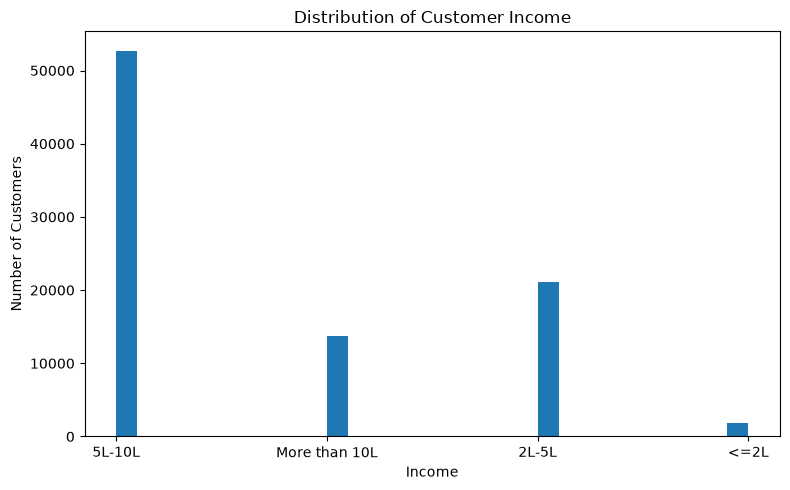

In [18]:
if "income" in train.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(train["income"].dropna(), bins=30)
    plt.title("Distribution of Customer Income")
    plt.xlabel("Income")
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()


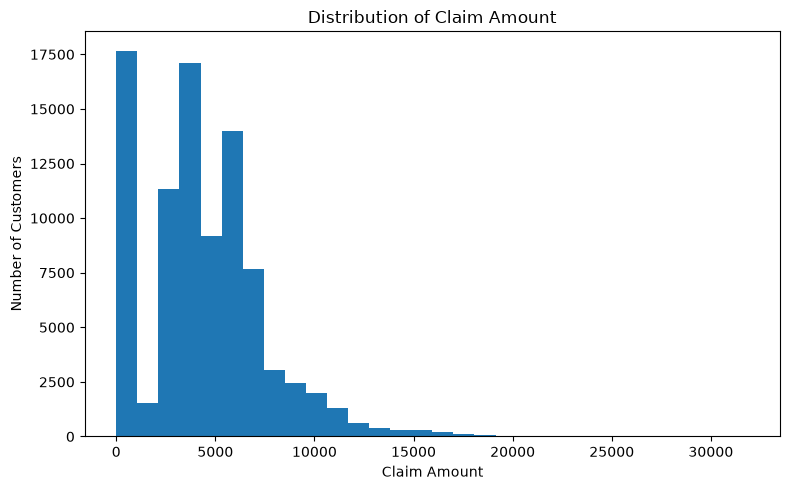

In [19]:
if "claim_amount" in train.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(train["claim_amount"].dropna(), bins=30)
    plt.title("Distribution of Claim Amount")
    plt.xlabel("Claim Amount")
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()


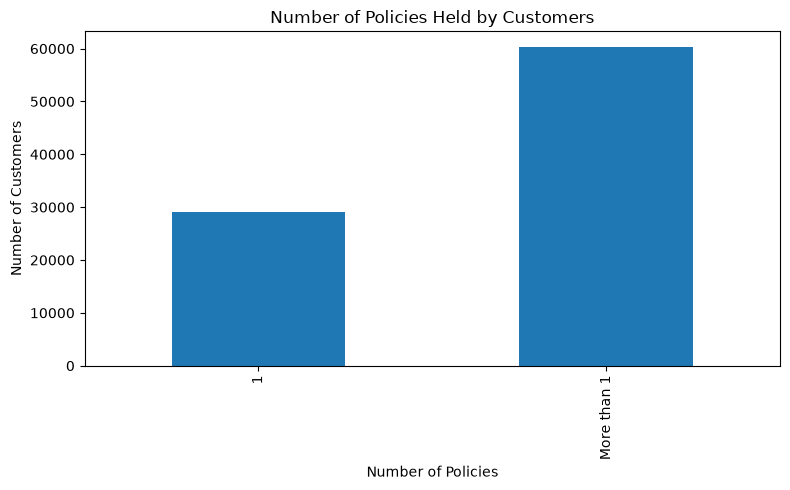

In [20]:
if "num_policies" in train.columns:
    plt.figure(figsize=(8, 5))
    train["num_policies"].value_counts().sort_index().plot(kind="bar")
    plt.title("Number of Policies Held by Customers")
    plt.xlabel("Number of Policies")
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()


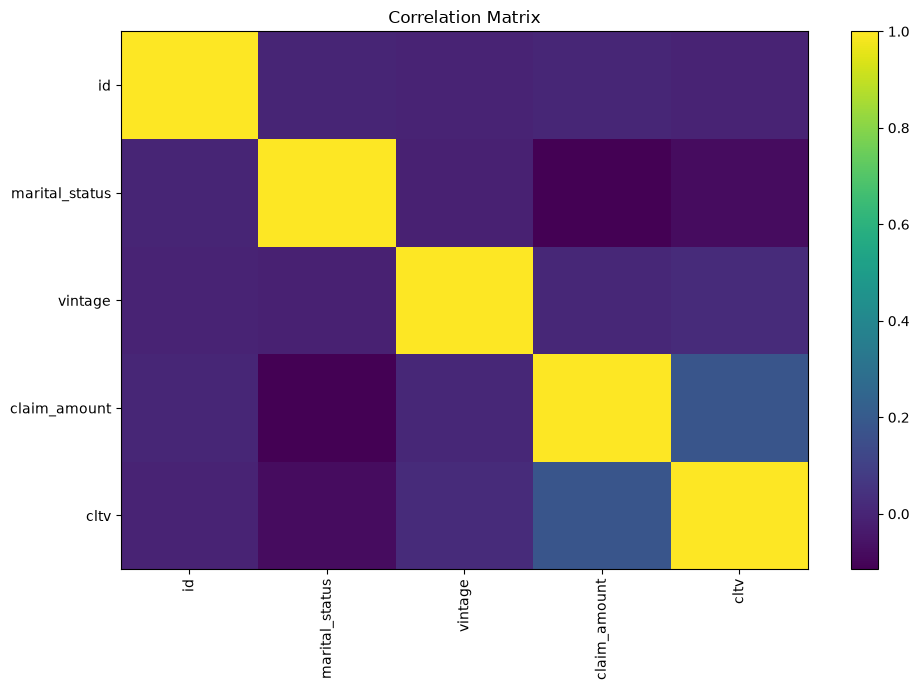

In [21]:
numeric_cols_eda = train.select_dtypes(include=np.number).columns

if len(numeric_cols_eda) > 1:
    corr = train[numeric_cols_eda].corr()
    plt.figure(figsize=(10, 7))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()


## 5. Data Quality Checks

The dataset is checked for:

- Missing values
- Duplicate records
- Data types
- Unexpected values
- Numerical and categorical features


In [22]:
print("Duplicate rows in training data:", train.duplicated().sum())
print("Duplicate rows in test data:", test.duplicated().sum())

print("\nTraining data types:")
display(train.dtypes)


Duplicate rows in training data: 0
Duplicate rows in test data: 0

Training data types:


id                int64
gender              str
area                str
qualification       str
income              str
marital_status    int64
vintage           int64
claim_amount      int64
num_policies        str
policy              str
type_of_policy      str
cltv              int64
dtype: object

## 6. Data Preprocessing

The preprocessing workflow includes:

1. Cleaning column names
2. Separating the customer ID
3. Converting numerical variables
4. Handling missing values
5. Separating the target variable


In [23]:
train.columns = train.columns.str.strip().str.lower()
test.columns = test.columns.str.strip().str.lower()

print("Training columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())


Training columns:
['id', 'gender', 'area', 'qualification', 'income', 'marital_status', 'vintage', 'claim_amount', 'num_policies', 'policy', 'type_of_policy', 'cltv']

Test columns:
['id', 'gender', 'area', 'qualification', 'income', 'marital_status', 'vintage', 'claim_amount', 'num_policies', 'policy', 'type_of_policy']


In [24]:
test_ids = test["id"].copy()

train = train.drop(columns=["id"])
test = test.drop(columns=["id"])

print("ID removed from model features.")


ID removed from model features.


In [25]:
num_cols = ["income", "claim_amount", "vintage", "num_policies"]

for col in num_cols:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors="coerce")
    if col in test.columns:
        test[col] = pd.to_numeric(test[col], errors="coerce")

existing_num_cols = [col for col in num_cols if col in train.columns]

train[existing_num_cols] = train[existing_num_cols].fillna(0)
test[existing_num_cols] = test[existing_num_cols].fillna(0)

print("Missing numerical values handled.")


Missing numerical values handled.


## 7. Feature Engineering

Additional customer-level features are created to help the model capture relationships between income, claims, policies, and customer vintage.


In [26]:
def create_features(df):
    df = df.copy()

    df["income_to_claim"] = df["income"] / (df["claim_amount"] + 1)
    df["claim_to_income"] = df["claim_amount"] / (df["income"] + 1)
    df["premium_per_policy"] = df["income"] / (df["num_policies"] + 1)
    df["policy_per_year"] = df["num_policies"] / (df["vintage"] + 1)

    df["income_log"] = np.log1p(df["income"].clip(lower=0))
    df["claim_log"] = np.log1p(df["claim_amount"].clip(lower=0))
    df["policies_log"] = np.log1p(df["num_policies"].clip(lower=0))

    df["income_per_year"] = df["income"] / (df["vintage"] + 1)
    df["claim_per_policy"] = df["claim_amount"] / (df["num_policies"] + 1)
    df["risk_score"] = df["claim_amount"] / (df["income"] + 1)

    return df

train = create_features(train)
test = create_features(test)

print("Feature engineering completed.")
print("Training shape after feature engineering:", train.shape)


Feature engineering completed.
Training shape after feature engineering: (89392, 21)


## 8. Target Variable Preparation

The target variable is `cltv`.

Because CLTV can be highly skewed, a log transformation is applied using `log1p()`. Predictions are later converted back to the original CLTV scale using `expm1()`.


In [27]:
y = train["cltv"].copy()
X = train.drop(columns=["cltv"]).copy()

y_log = np.log1p(y)

print("Original CLTV summary:")
display(y.describe())

print("\nLog-transformed CLTV summary:")
display(y_log.describe())


Original CLTV summary:


count    89,392.00
mean     97,952.83
std      90,613.81
min      24,828.00
25%      52,836.00
50%      66,396.00
75%     103,440.00
max     724,068.00
Name: cltv, dtype: float64


Log-transformed CLTV summary:


count   89,392.00
mean        11.24
std          0.65
min         10.12
25%         10.87
50%         11.10
75%         11.55
max         13.49
Name: cltv, dtype: float64

## 9. Categorical Encoding

Categorical variables are converted into numerical columns using one-hot encoding.

The training and test datasets are aligned so that both contain the same feature columns.


In [28]:
X = pd.get_dummies(X, drop_first=False)
test_encoded = pd.get_dummies(test, drop_first=False)

X, test_encoded = X.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

X = X.fillna(0)
test_encoded = test_encoded.fillna(0)

print("Encoded training shape:", X.shape)
print("Encoded test shape:", test_encoded.shape)


Encoded training shape: (89392, 28)
Encoded test shape: (59595, 28)


## 10. Train-Validation Split

The data is divided into 80% training data and 20% validation data.


In [29]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Training samples: 71513
Validation samples: 17879


## 11. Model Training

### LightGBM Regressor

LightGBM is a gradient boosting framework designed for efficient learning on structured and tabular datasets.

It was selected because it can model nonlinear relationships and interactions between features effectively.


In [30]:
model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed.")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1326
[LightGBM] [Info] Number of data points in the train set: 71513, number of used features: 23
[LightGBM] [Info] Start training from score 11.239210
Model training completed.


## 12. Model Evaluation

The primary evaluation metric is the **R² score**.


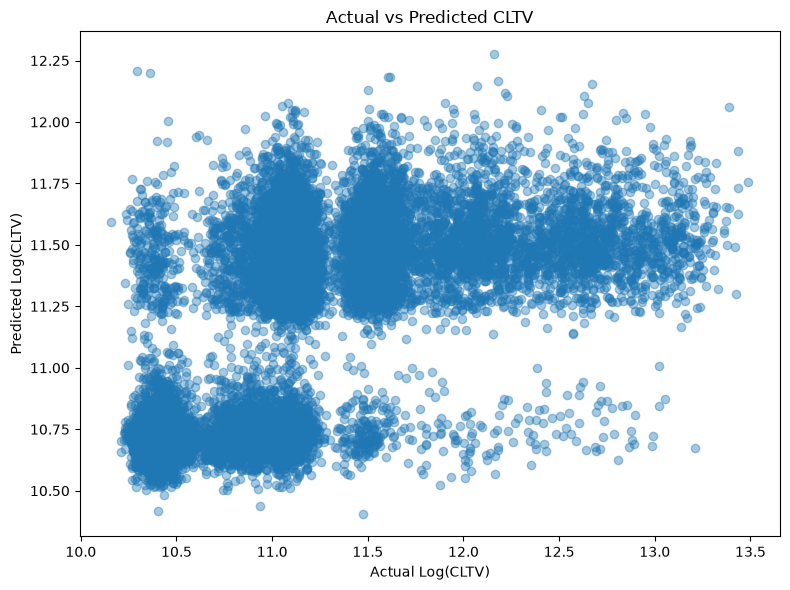

Validation R² Score: 0.3144


In [42]:
val_preds = model.predict(X_val)

plt.figure(figsize=(8, 6))

plt.scatter(y_val, val_preds, alpha=0.4)

plt.xlabel("Actual Log(CLTV)")
plt.ylabel("Predicted Log(CLTV)")
plt.title("Actual vs Predicted CLTV")

plt.tight_layout()
plt.savefig("../images/model_performance.png", dpi=300, bbox_inches="tight")
plt.show()

validation_r2 = r2_score(y_val, val_preds)

print(f"Validation R² Score: {validation_r2:.4f}")


## 13. Feature Importance

In [32]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))


,Feature,Importance
3,claim_amount,14563
13,claim_per_policy,10741
2,vintage,10329
15,gender_Female,3851
1,marital_status,3577
26,type_of_policy_Platinum,2527
19,qualification_Bachelor,2276
22,policy_A,2148
20,qualification_High School,1868
25,type_of_policy_Gold,1666


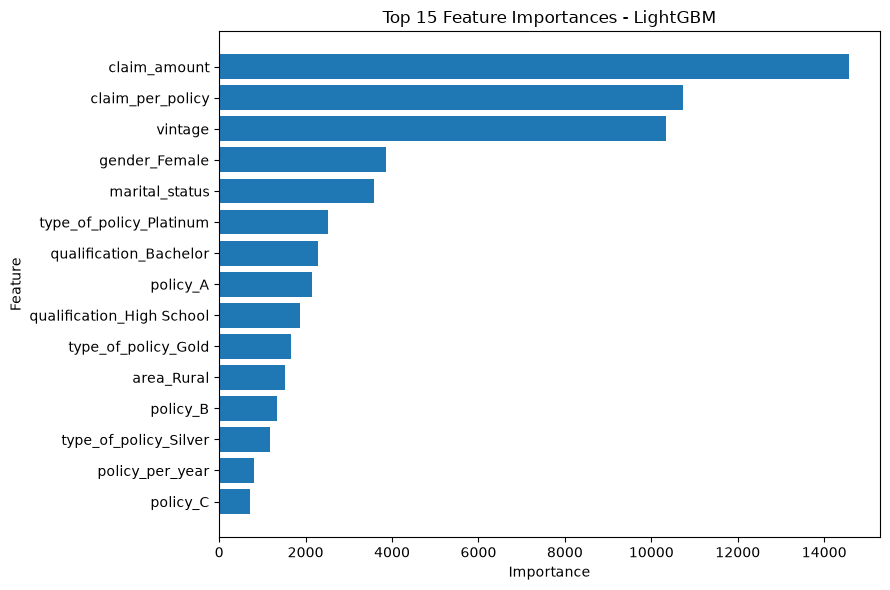

In [33]:
top_n = 15
plot_df = importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.title("Top 15 Feature Importances - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

os.makedirs("../images", exist_ok=True)
plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## 14. Final Model Training

After validation, the final model is trained using the complete training dataset before generating predictions for the unseen test dataset.


In [34]:
final_model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    random_state=42
)

final_model.fit(X, y_log)

print("Final model trained on the complete training dataset.")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1326
[LightGBM] [Info] Number of data points in the train set: 89392, number of used features: 23
[LightGBM] [Info] Start training from score 11.237349
Final model trained on the complete training dataset.


## 15. Test Prediction

Predictions are generated for the unseen test dataset and converted back to the original CLTV scale.


In [35]:
test_preds_log = final_model.predict(test_encoded)
test_preds = np.expm1(test_preds_log)

print("Prediction generation completed.")
print("Number of predictions:", len(test_preds))


Prediction generation completed.
Number of predictions: 59595


## 16. Prediction Output

The final prediction file contains:

| Column | Description |
|---|---|
| `id` | Customer identifier |
| `cltv` | Predicted Customer Lifetime Value |


In [36]:
submission = pd.DataFrame({
    "id": test_ids,
    "cltv": test_preds
})

display(submission.head(10))


,id,cltv
0,89393,"74,554.20"
1,89394,"108,911.39"
2,89395,"85,283.80"
3,89396,"78,872.93"
4,89397,"92,157.28"
5,89398,"101,036.90"
6,89399,"44,153.19"
7,89400,"91,427.53"
8,89401,"42,960.59"
9,89402,"112,895.63"


In [37]:
os.makedirs("../outputs", exist_ok=True)

submission.to_csv(
    "../outputs/submission.csv",
    index=False
)

print("Submission file saved to ../outputs/submission.csv")


Submission file saved to ../outputs/submission.csv


## 17. Prediction Summary

In [38]:
display(submission["cltv"].describe())


count    59,595.00
mean     81,366.19
std      27,858.17
min      32,713.76
25%      47,663.57
50%      87,982.21
75%     100,891.90
max     240,532.23
Name: cltv, dtype: float64

## 18. Business Insights

The model can support customer-level value analysis.

Potential insights include:

1. Customers with higher predicted CLTV can be considered potential high-value customer segments.
2. Feature importance can help identify customer characteristics that contribute strongly to model predictions.
3. CLTV predictions can support customer segmentation and marketing prioritization.
4. Predicted customer value can be combined with other customer behavior information to develop more targeted strategies.

These insights should be interpreted together with the actual feature-importance results and customer prediction distribution.


## 19. Business Recommendations

Based on the purpose of the CLTV prediction model, businesses can consider:

- Prioritizing high-CLTV customers for retention campaigns.
- Developing personalized offers for valuable customer segments.
- Using predicted CLTV to support marketing resource allocation.
- Designing customer segments based on expected lifetime value.
- Monitoring customer value over time.
- Retraining the model as new customer data becomes available.


## 20. Conclusion

This project demonstrates an end-to-end machine learning workflow for Customer Lifetime Value prediction.

The workflow includes data preprocessing, exploratory data analysis, feature engineering, categorical encoding, target transformation, LightGBM regression, model evaluation, feature importance analysis, test prediction, and submission file generation.

The resulting CLTV predictions can potentially support customer segmentation, retention strategies, marketing prioritization, and data-driven customer relationship decisions.


## 21. Portfolio Project Summary

**Project:** Customer Lifetime Value (CLTV) Prediction

**Model:** LightGBM Regressor

**Evaluation Metric:** R² Score

**Validation R²:** Approximately 0.3134 in the original validation run

**Key Skills Demonstrated:**

- Python
- Pandas
- NumPy
- Exploratory Data Analysis
- Data Preprocessing
- Feature Engineering
- Machine Learning
- LightGBM
- Model Evaluation
- Feature Importance
- Business Insights
